In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from src.community_detection import CommunityDetection
from src.ansatze import Ansatz
from src.simulator import QuimbSimulator
from src.optimizer import COBYLA, SMO
from src.lvqe import LayerVQE


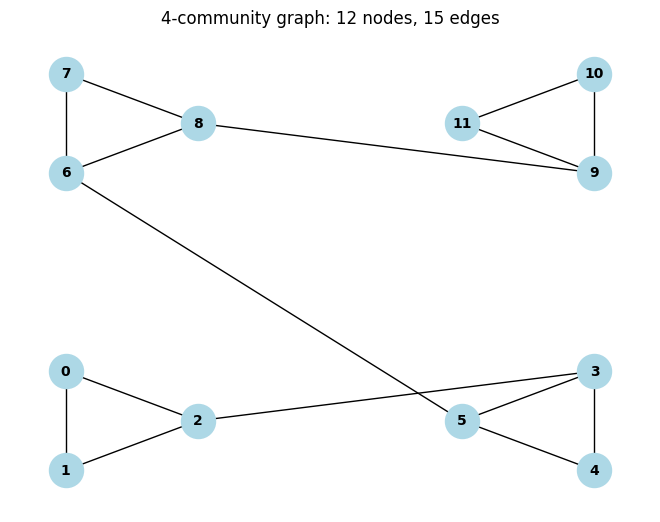

In [9]:
import networkx as nx

G = nx.Graph()

# 4 cliques of 3 nodes each
communities = {
    0: [0, 1, 2],
    1: [3, 4, 5],
    2: [6, 7, 8],
    3: [9, 10, 11]
}

# fully connect each cluster
for nodes in communities.values():
    for i in nodes:
        for j in nodes:
            if i < j:
                G.add_edge(i, j)

# connect clusters with single bridge edges to keep graph connected
G.add_edge(2, 3)   # cluster 0 → cluster 1
G.add_edge(5, 6)   # cluster 1 → cluster 2
G.add_edge(8, 9)   # cluster 2 → cluster 3

# fixed spatial positions
pos = {
    0: (0, 1), 1: (0, 0), 2: (0.5, 0.5),
    3: (2, 1), 4: (2, 0), 5: (1.5, 0.5),
    6: (0, 3), 7: (0, 4), 8: (0.5, 3.5),
    9: (2, 3), 10: (2, 4), 11: (1.5, 3.5),
}

nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=600, font_size=10, font_weight='bold')
plt.title(f"4-community graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
plt.show()


n_qubits: 24
n_terms: 199
best known modularity (Louvain): -0.5489
Starting L-VQE: 2 layers, 200 iter/layer, 300 final iter
Mode: exact expectation

Layer 0: 



COBYLA: 100%|██████████| 200/200 [01:03<00:00,  3.17it/s, best_E=-0.5477]


Total evaluations: 200
layer 0: energy=-0.5477, approx_ratio=+0.9977

Layer 1 — 200 iterations (before convergence)


COBYLA: 100%|██████████| 200/200 [01:08<00:00,  2.91it/s, best_E=-0.5480]


Total evaluations: 200
layer 1: energy=-0.5480, approx_ratio=+0.9985

Final layer — 300 iterations (final)


COBYLA: 100%|██████████| 300/300 [01:52<00:00,  2.66it/s, best_E=-0.5481]

Total evaluations: 300
layer 2: energy=-0.5481, approx_ratio=+0.9986

Final approximation ratio: 0.9986


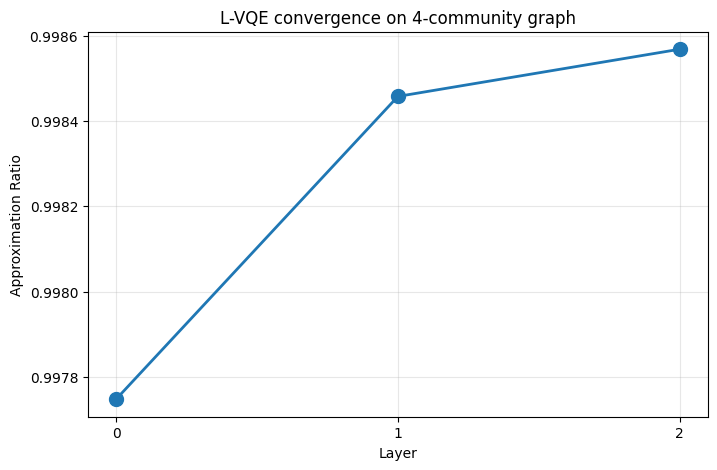

In [14]:

N_LAYERS=2
K_PER_LAYER=200
K_FINAL=300
k = 4
problem = CommunityDetection(G, k)
print(f"\nn_qubits: {problem.num_qubits}")
print(f"n_terms: {len(problem.hamiltonian_terms)}")

# for 20 nodes, brute force is infeasible — use Louvain heuristic
# (best_known_value will switch to Louvain automatically if n_nodes > 12)
best_known = problem.best_known_value
print(f"best known modularity (Louvain): {best_known:.4f}")

# run L-VQE
sim = QuimbSimulator()
lvqe = LayerVQE(
    problem=problem,
    simulator=sim,
    optimizer_class=COBYLA,
    n_layers=N_LAYERS,
    k_per_layer=K_PER_LAYER,
    k_final=K_FINAL,
    use_sampling=False,
    record_loss=True
)

result = lvqe.run()

print(f"\nFinal approximation ratio: {result['final_approx_ratio']:.4f}")

# plot the convergence
plt.figure(figsize=(8, 5))
plt.plot(result['history']['layer'], result['history']['approx_ratio'], 
         'o-', linewidth=2, markersize=10)
plt.xlabel('Layer')
plt.ylabel('Approximation Ratio')
plt.title('L-VQE convergence on 4-community graph')
plt.grid(True, alpha=0.3)
plt.xticks(result['history']['layer'])
plt.show()

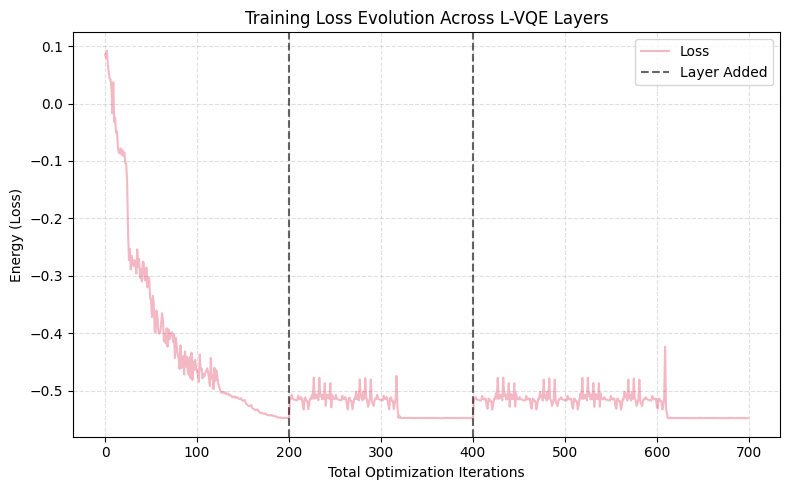

In [15]:
plt.figure(figsize=(8, 5))

optimizer_loss = result['history']['optimizer_loss']
continuous_loss = np.concatenate(optimizer_loss)
plt.plot(continuous_loss, color='crimson', alpha=0.3, linewidth=1.5, label='Loss')

transition_points = [K_PER_LAYER * layer for layer in range(1, N_LAYERS + 1)]

for idx, pt in enumerate(transition_points):
    plt.axvline(x=pt, color='black', linestyle='--', alpha=0.6,
                label='Layer Added' if idx == 0 else "")

plt.xlabel('Total Optimization Iterations')
plt.ylabel('Energy (Loss)')
plt.title(f'Training Loss Evolution Across L-VQE Layers')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

LVQE decoded communities (most probable sample):
  Community 0: [9, 10, 11]
  Community 1: [3, 4, 5]
  Community 2: [6, 7, 8]
  Community 3: [0, 1, 2]
LVQE decoded modularity Q = 0.5489 (probability: 99.750%)
LVQE final energy (expectation) = -0.5481
Best-known modularity Q*        = 0.5489
Approximation ratio (energy)    = 0.9986
Approximation ratio (decoded)   = 1.0000


/tmp/ipykernel_66464/969823548.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", max(n_colors, 2))


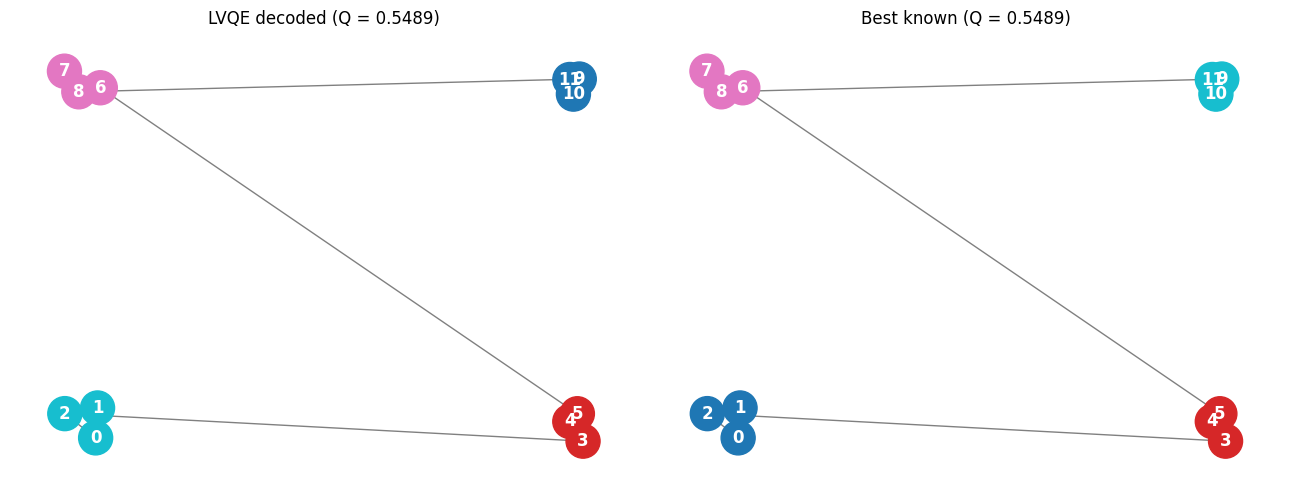

In [16]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from networkx.algorithms.community import louvain_communities

def to_communities(assignment):
    groups = {}
    for node, label in enumerate(assignment):
        groups.setdefault(label, []).append(node)
    return groups

# L-VQE decoded
bitstrings = sim.get_most_frequent_assignments(
    result['final_params'], result['final_ansatz'], problem=problem
)

best_assignment, best_proba = bitstrings[0]
modularity_lvqe = problem.evaluate(best_assignment)
communities_lvqe = to_communities(best_assignment)
q_best = -problem.best_known_value

print("LVQE decoded communities (most probable sample):")
for label, nodes in sorted(communities_lvqe.items()):
    print(f"  Community {label}: {nodes}")
print(f"LVQE decoded modularity Q = {modularity_lvqe:.4f} (probability: {best_proba:.3f}%)")
print(f"LVQE final energy (expectation) = {result['final_energy']:.4f}")
print(f"Best-known modularity Q*        = {q_best:.4f}")
print(f"Approximation ratio (energy)    = {result['final_approx_ratio']:.4f}")
print(f"Approximation ratio (decoded)   = {modularity_lvqe / q_best:.4f}")

# recover the best-known assignment via Louvain
best_assignment_exact = [0] * problem.num_nodes
for comm_idx, comm in enumerate(louvain_communities(G, seed=problem.seed)):
    for node in comm:
        best_assignment_exact[node] = comm_idx
best_q = problem.evaluate(best_assignment_exact)

def draw_partition(ax, assignment, title):
    n_colors = max(assignment) + 1
    cmap = cm.get_cmap("tab10", max(n_colors, 2))
    node_colors = [cmap(assignment[node]) for node in G.nodes()]
    nx.draw_networkx(
        G, pos=pos, node_color=node_colors, with_labels=True,
        node_size=600, font_color="white", font_weight="bold",
        edge_color="gray", ax=ax,
    )
    ax.set_title(title)
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
draw_partition(axes[0], best_assignment, f"LVQE decoded (Q = {modularity_lvqe:.4f})")
draw_partition(axes[1], best_assignment_exact, f"Best known (Q = {best_q:.4f})")
plt.tight_layout()
plt.show()